#  CHILD MALNUTRITION ANALYSIS - ETHIOPIA 

##  Dataset Overview
- **4,098 children** under age 5
- **Clinical indicators:** Anemia, Malaria, Diarrhea, TB
- **Socioeconomic factors:** Region, Mother Education, Household Wealth
- **Physical measurements:** Height, Weight, Age

---

##  What We'll Discover
1. Which children are most at risk of malnutrition?
2. How do diseases (anemia, malaria, diarrhea, TB) affect nutrition?
3. Does mother's education matter?
4. What combination of factors creates highest risk?

In [1]:
# ============================================
# IMPORT LIBRARIES & LOAD DATA
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/programmer3/malnutrition-risk-in-ethiopian-children/malnutrition_children_ethiopia.csv')

print("="*50)
print(" CHILD MALNUTRITION DATASET LOADED!")
print("="*50)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

 CHILD MALNUTRITION DATASET LOADED!
Shape: (4098, 16)
Columns: ['ID', 'Age (months)', 'Gender', 'Region', 'Mother_Education', 'Household_Wealth_Index', 'Height_cm', 'Weight_kg', 'Stunting', 'Underweight', 'Overweight', 'Anemia', 'Malaria', 'Diarrhea', 'TB', 'Nutrition_Status']

First 5 rows:


,ID,Age (months),Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Underweight,Overweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
0,1,31,Male,Amhara,Higher,Middle,84.1,19.2,1,1,0,1,1,1,1,At_Risk
1,2,38,Female,Tigray,Higher,Middle,91.0,6.3,0,0,0,0,1,1,0,Normal
2,3,7,Female,SNNPR,Secondary,Middle,61.4,5.8,1,1,1,1,1,0,1,Normal
3,4,7,Female,Amhara,Higher,Low,103.1,12.9,1,0,1,1,0,1,0,Normal
4,5,0,Male,Tigray,No education,High,78.9,7.4,0,0,0,0,1,1,0,Normal


In [2]:
# ============================================
# DATA OVERVIEW & CLEANING
# ============================================
print("="*50)
print("DATA OVERVIEW")
print("="*50)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNutrition Status distribution:")
print(df['Nutrition_Status'].value_counts())

print("\nDisease prevalence:")
print(f"Anemia: {df['Anemia'].value_counts()}")
print(f"Malaria: {df['Malaria'].value_counts()}")
print(f"Diarrhea: {df['Diarrhea'].value_counts()}")
print(f"TB: {df['TB'].value_counts()}")

print("\nStatistical summary:")
print(df.describe())

DATA OVERVIEW

Missing values:
ID                        0
Age (months)              0
Gender                    0
Region                    0
Mother_Education          0
Household_Wealth_Index    0
Height_cm                 0
Weight_kg                 0
Stunting                  0
Underweight               0
Overweight                0
Anemia                    0
Malaria                   0
Diarrhea                  0
TB                        0
Nutrition_Status          0
dtype: int64

Nutrition Status distribution:
Nutrition_Status
Normal          2030
At_Risk         1238
Malnourished     830
Name: count, dtype: int64

Disease prevalence:
Anemia: Anemia
1    2065
0    2033
Name: count, dtype: int64
Malaria: Malaria
1    2066
0    2032
Name: count, dtype: int64
Diarrhea: Diarrhea
0    2059
1    2039
Name: count, dtype: int64
TB: TB
1    2061
0    2037
Name: count, dtype: int64

Statistical summary:
               ID  Age (months)    Height_cm    Weight_kg     Stunting  \
count  4098

##  TECHNIQUE 1: CROSS-TABULATION
### Question: How does region and disease affect malnutrition?

**Why this matters:** Averages hide interaction effects. A child in one region with diarrhea has different risk than another.

**What we're testing:**
- Region vs Nutrition Status
- Disease (Anemia, Malaria, Diarrhea, TB) vs Nutrition Status

TECHNIQUE 1: CROSS-TABULATION

Nutrition Status by Region (%):
Nutrition_Status  At_Risk  Malnourished  Normal
Region                                         
Addis Ababa          31.1          20.3    48.6
Amhara               30.2          19.6    50.2
Oromia               28.9          22.6    48.5
SNNPR                30.5          19.3    50.2
Tigray               30.4          19.6    50.1

Nutrition Status by Anemia (%):
Nutrition_Status  At_Risk  Malnourished  Normal
Anemia                                         
0                    28.6          20.5    50.9
1                    31.8          20.0    48.2

Nutrition Status by Malaria (%):
Nutrition_Status  At_Risk  Malnourished  Normal
Malaria                                        
0                    30.1          20.2    49.7
1                    30.3          20.3    49.4

Nutrition Status by Diarrhea (%):
Nutrition_Status  At_Risk  Malnourished  Normal
Diarrhea                                       
0                  

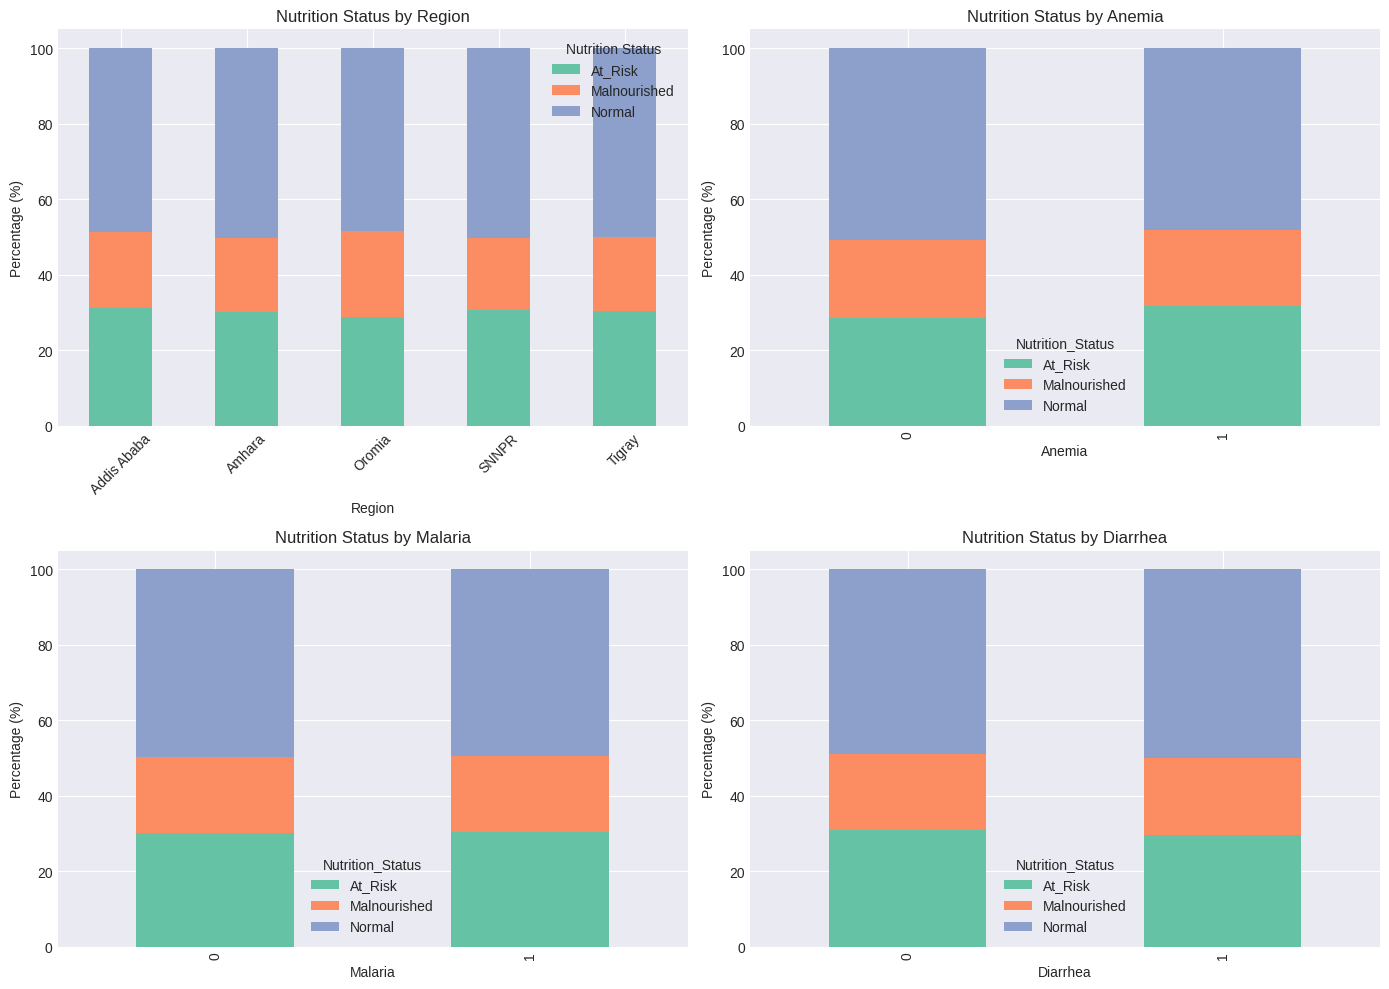

In [3]:
# ============================================
# TECHNIQUE 1: CROSS-TABULATION
# ============================================
print("="*50)
print("TECHNIQUE 1: CROSS-TABULATION")
print("="*50)

# Region vs Nutrition Status
cross_region = pd.crosstab(df['Region'], df['Nutrition_Status'], normalize='index') * 100
print("\nNutrition Status by Region (%):")
print(cross_region.round(1))

# Anemia vs Nutrition Status
cross_anemia = pd.crosstab(df['Anemia'], df['Nutrition_Status'], normalize='index') * 100
print("\nNutrition Status by Anemia (%):")
print(cross_anemia.round(1))

# Malaria vs Nutrition Status
cross_malaria = pd.crosstab(df['Malaria'], df['Nutrition_Status'], normalize='index') * 100
print("\nNutrition Status by Malaria (%):")
print(cross_malaria.round(1))

# Diarrhea vs Nutrition Status
cross_diarrhea = pd.crosstab(df['Diarrhea'], df['Nutrition_Status'], normalize='index') * 100
print("\nNutrition Status by Diarrhea (%):")
print(cross_diarrhea.round(1))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Region plot
cross_region.plot(kind='bar', ax=axes[0,0], stacked=True)
axes[0,0].set_title('Nutrition Status by Region', fontsize=12)
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].legend(title='Nutrition Status')
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45)

# Anemia plot
cross_anemia.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Nutrition Status by Anemia', fontsize=12)
axes[0,1].set_ylabel('Percentage (%)')

# Malaria plot
cross_malaria.plot(kind='bar', ax=axes[1,0], stacked=True)
axes[1,0].set_title('Nutrition Status by Malaria', fontsize=12)
axes[1,0].set_ylabel('Percentage (%)')

# Diarrhea plot
cross_diarrhea.plot(kind='bar', ax=axes[1,1], stacked=True)
axes[1,1].set_title('Nutrition Status by Diarrhea', fontsize=12)
axes[1,1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

##  TECHNIQUE 2: PERCENTILE ANALYSIS
### Question: What are the characteristics of the most at-risk children?

**Why this matters:** Averages hide extremes. The top 10% most at-risk children might have different patterns.

**What we're testing:**
- Age distribution of malnourished children
- Height and weight percentiles

TECHNIQUE 2: PERCENTILE ANALYSIS

Age (months) Percentiles:
  25th percentile: 15 months
  50th percentile: 30 months
  75th percentile: 45 months
  90th percentile: 54 months
  95th percentile: 56 months

Height (cm) Percentiles:
  25th percentile: 71.9 cm
  50th percentile: 84.3 cm
  75th percentile: 97.1 cm
  90th percentile: 105.0 cm
  95th percentile: 107.6 cm

Weight (kg) Percentiles:
  25th percentile: 8.7 kg
  50th percentile: 12.4 kg
  75th percentile: 16.3 kg
  90th percentile: 18.6 kg
  95th percentile: 19.3 kg

Malnourished children by age group:
Age_Group
0-12 mo     163
13-24 mo    170
25-36 mo    175
37-48 mo    143
49-60 mo    166
dtype: int64


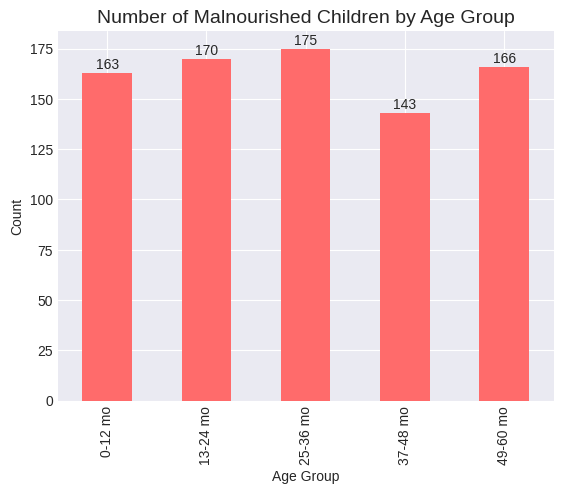

In [4]:
# ============================================
# TECHNIQUE 2: PERCENTILE ANALYSIS
# ============================================
print("="*50)
print("TECHNIQUE 2: PERCENTILE ANALYSIS")
print("="*50)

# Age percentiles
print("\nAge (months) Percentiles:")
for p in [25, 50, 75, 90, 95]:
    val = df['Age (months)'].quantile(p/100)
    print(f"  {p}th percentile: {val:.0f} months")

# Height percentiles
print("\nHeight (cm) Percentiles:")
for p in [25, 50, 75, 90, 95]:
    val = df['Height_cm'].quantile(p/100)
    print(f"  {p}th percentile: {val:.1f} cm")

# Weight percentiles
print("\nWeight (kg) Percentiles:")
for p in [25, 50, 75, 90, 95]:
    val = df['Weight_kg'].quantile(p/100)
    print(f"  {p}th percentile: {val:.1f} kg")

# Create age groups
df['Age_Group'] = pd.cut(df['Age (months)'], bins=[0, 12, 24, 36, 48, 60], 
                           labels=['0-12 mo', '13-24 mo', '25-36 mo', '37-48 mo', '49-60 mo'])

# Malnutrition by age group
age_malnutrition = df[df['Nutrition_Status'] == 'Malnourished'].groupby('Age_Group').size()
print("\nMalnourished children by age group:")
print(age_malnutrition)

# Visualization
age_malnutrition.plot(kind='bar', color='#ff6b6b')
plt.title('Number of Malnourished Children by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Count')
for i, v in enumerate(age_malnutrition):
    plt.text(i, v + 2, str(v), ha='center')
plt.show()

##  TECHNIQUE 3: DERIVED METRICS
### Question: What is the relationship between weight, height, and malnutrition?

**Why this matters:** Raw numbers hide efficiency. Ratios reveal health status.

**What we're creating:**
- Weight-for-Age ratio
- Height-for-Age ratio
- BMI for children

TECHNIQUE 3: DERIVED METRICS

Average metrics by Nutrition Status:
                  Weight_For_Age  Height_For_Age  BMI_Child
Nutrition_Status                                           
At_Risk                     0.95            6.72      19.25
Malnourished                0.95            6.45      19.40
Normal                      1.02            6.89      19.03


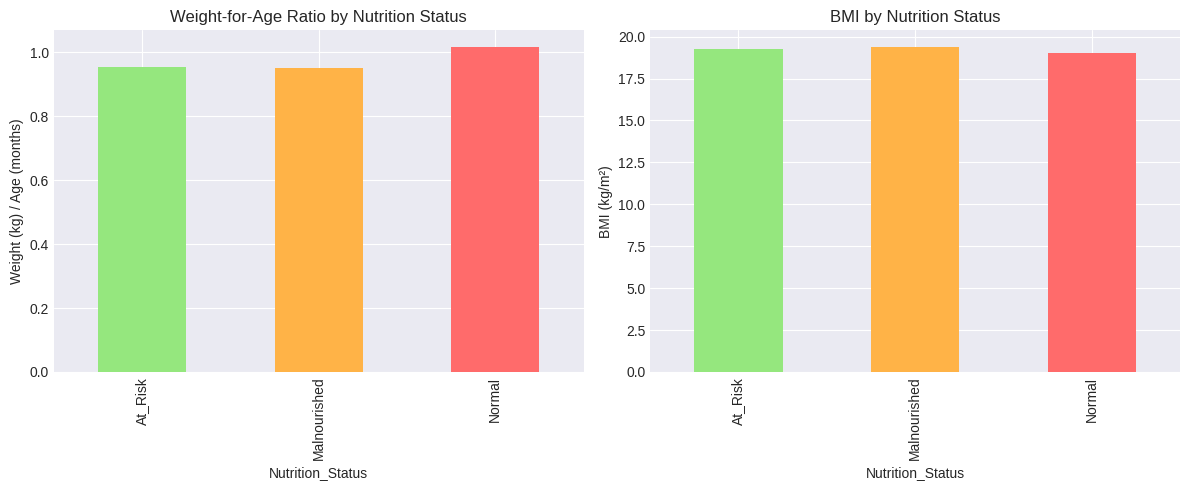

In [5]:
# ============================================
# TECHNIQUE 3: DERIVED METRICS
# ============================================
print("="*50)
print("TECHNIQUE 3: DERIVED METRICS")
print("="*50)

# Create derived metrics
df['Weight_For_Age'] = df['Weight_kg'] / (df['Age (months)'] + 1)
df['Height_For_Age'] = df['Height_cm'] / (df['Age (months)'] + 1)
df['BMI_Child'] = df['Weight_kg'] / ((df['Height_cm']/100) ** 2)

print("\nAverage metrics by Nutrition Status:")
metrics = df.groupby('Nutrition_Status')[['Weight_For_Age', 'Height_For_Age', 'BMI_Child']].mean()
print(metrics.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Weight for Age
df.groupby('Nutrition_Status')['Weight_For_Age'].mean().plot(kind='bar', ax=axes[0], color=['#95e77e', '#ffb347', '#ff6b6b'])
axes[0].set_title('Weight-for-Age Ratio by Nutrition Status', fontsize=12)
axes[0].set_ylabel('Weight (kg) / Age (months)')

# BMI
df.groupby('Nutrition_Status')['BMI_Child'].mean().plot(kind='bar', ax=axes[1], color=['#95e77e', '#ffb347', '#ff6b6b'])
axes[1].set_title('BMI by Nutrition Status', fontsize=12)
axes[1].set_ylabel('BMI (kg/m²)')

plt.tight_layout()
plt.show()

##  TECHNIQUE 4: COHORT ANALYSIS
### Question: How does mother's education and household wealth affect child nutrition?

**Why this matters:** Socioeconomic factors often predict child health outcomes.

**What we're testing:**
- Mother Education vs Nutrition Status
- Household Wealth Index vs Nutrition Status

TECHNIQUE 4: COHORT ANALYSIS

Nutrition Status by Mother Education (%):
Nutrition_Status  At_Risk  Malnourished  Normal
Mother_Education                               
Higher               29.5          21.6    48.9
No education         31.6          18.1    50.3
Primary              30.5          20.8    48.7
Secondary            29.3          20.4    50.3

Nutrition Status by Household Wealth Index (%):
Nutrition_Status        At_Risk  Malnourished  Normal
Household_Wealth_Index                               
High                       29.1          20.1    50.8
Low                        30.0          20.9    49.1
Middle                     31.5          19.7    48.8


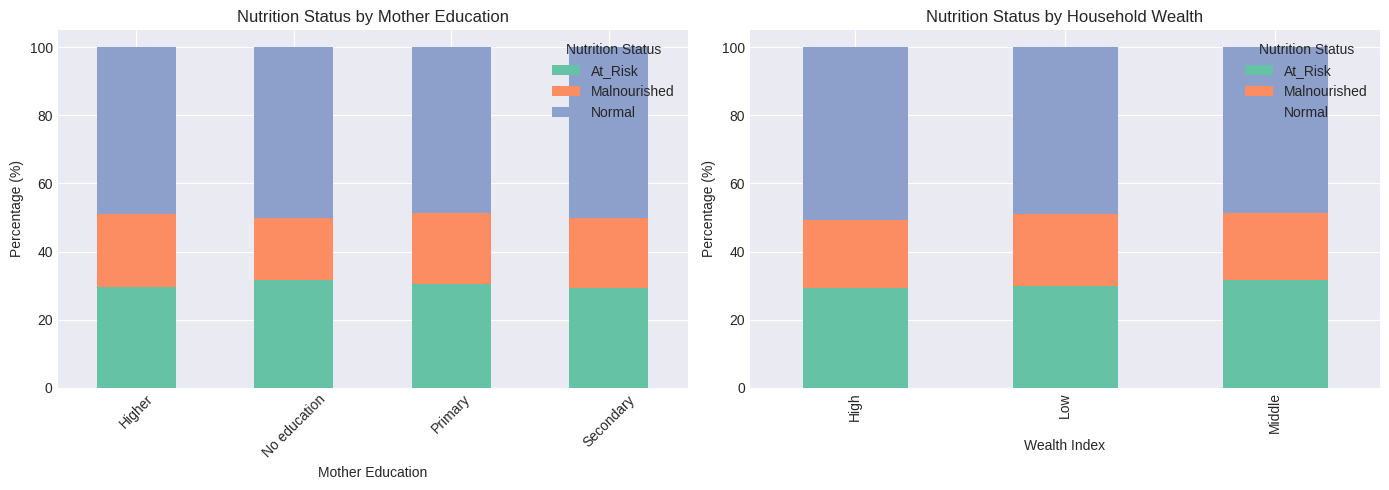

In [6]:
# ============================================
# TECHNIQUE 4: COHORT ANALYSIS
# ============================================
print("="*50)
print("TECHNIQUE 4: COHORT ANALYSIS")
print("="*50)

# Mother Education vs Nutrition Status
edu_nutrition = pd.crosstab(df['Mother_Education'], df['Nutrition_Status'], normalize='index') * 100
print("\nNutrition Status by Mother Education (%):")
print(edu_nutrition.round(1))

# Household Wealth Index vs Nutrition Status
wealth_nutrition = pd.crosstab(df['Household_Wealth_Index'], df['Nutrition_Status'], normalize='index') * 100
print("\nNutrition Status by Household Wealth Index (%):")
print(wealth_nutrition.round(1))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Education plot
edu_nutrition.plot(kind='bar', ax=axes[0], stacked=True)
axes[0].set_title('Nutrition Status by Mother Education', fontsize=12)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Mother Education')
axes[0].legend(title='Nutrition Status')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Wealth plot
wealth_nutrition.plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Nutrition Status by Household Wealth', fontsize=12)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Wealth Index')
axes[1].legend(title='Nutrition Status')

plt.tight_layout()
plt.show()

TECHNIQUE 5: MULTI-DIMENSIONAL ANALYSIS

Risk Score distribution by Nutrition Status:
                   count       mean        std  min   25%   50%   75%    max
Nutrition_Status                                                            
At_Risk           1238.0  46.890145  22.425247  0.0  25.0  45.0  60.0  100.0
Malnourished       830.0  45.927711  22.714881  0.0  25.0  45.0  60.0  100.0
Normal            2030.0  46.125616  22.197565  0.0  30.0  45.0  60.0  100.0

Anemia rate by Region and Wealth Index (%):
Anemia                                 0     1
Region      Household_Wealth_Index            
Addis Ababa High                    51.0  49.0
            Low                     52.9  47.1
            Middle                  49.0  51.0
Amhara      High                    51.9  48.1
            Low                     45.8  54.2
            Middle                  50.9  49.1
Oromia      High                    45.8  54.2
            Low                     50.9  49.1
            Mi

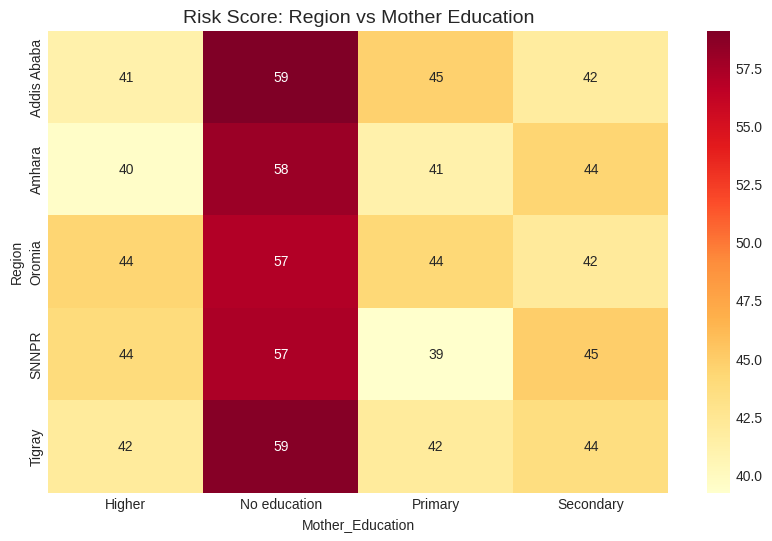

In [7]:
# ============================================
# TECHNIQUE 5: MULTI-DIMENSIONAL ANALYSIS
# ============================================
print("="*50)
print("TECHNIQUE 5: MULTI-DIMENSIONAL ANALYSIS")
print("="*50)

# Create risk score
df['Risk_Score'] = (
    (df['Anemia'] == 1).astype(int) * 25 +
    (df['Malaria'] == 1).astype(int) * 25 +
    (df['Diarrhea'] == 1).astype(int) * 20 +
    (df['TB'] == 1).astype(int) * 15 +
    (df['Mother_Education'] == 'No education').astype(int) * 15
)

print("\nRisk Score distribution by Nutrition Status:")
print(df.groupby('Nutrition_Status')['Risk_Score'].describe())

# 3D analysis: Region + Wealth + Disease
multi = pd.crosstab([df['Region'], df['Household_Wealth_Index']], df['Anemia'], normalize='index') * 100
print("\nAnemia rate by Region and Wealth Index (%):")
print(multi.round(1))

# Heatmap
pivot = df.pivot_table(index='Region', columns='Mother_Education', values='Risk_Score', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Risk Score: Region vs Mother Education', fontsize=14)
plt.show()

